### 本notebook进行独立训练（Individual Training）
在独立学习中，每个客户只能访问自己的私有数据集进行训练

In [1]:
import sys
import os

from pathlib import Path

parent = Path(os.path.abspath("")).resolve().parents[0]
if parent not in sys.path:
    sys.path.insert(0, str(parent))

In [ ]:
import random

import numpy as np
import torch

from argparse import Namespace

In [3]:
from ml.utils.data_utils import read_data, generate_time_lags, time_to_feature, handle_nans, to_Xy, \
    to_torch_dataset, to_timeseries_rep, assign_statistics, \
    to_train_val, scale_features, get_data_by_area, remove_identifiers, get_exogenous_data_by_area, handle_outliers

In [4]:
from ml.utils.train_utils import train, test

In [5]:
from ml.models.mlp import MLP
from ml.models.rnn import RNN
from ml.models.lstm import LSTM
from ml.models.gru import GRU
from ml.models.cnn import CNN
from ml.models.rnn_autoencoder import DualAttentionAutoEncoder

In [ ]:
args = Namespace(
    data_path='../CBL-dataset/LCL-June2015v2_0.csv', # 电力数据集路径
    data_path_test=None, # 测试数据集（可选）
    test_size=0.2, # 验证集比例
    targets=['kwh'], # 目标列：用电量
    num_lags=10, # 用于输入的过去观测值数量

    
    filter_bs=None, # 是否使用单个客户进行训练，将在后续动态更改
    identifier='customer_id', # 标识客户的列名

    nan_constant=0, # 用于转换NaN值的常数
    x_scaler='minmax', # X特征缩放器
    y_scaler='minmax', # y目标缩放器
    outlier_detection=None, # 是否执行异常值处理（flooring and capping）

    
    criterion='mse', # 优化准则，mse或l1
    epochs=10, # 最大训练轮数
    lr=0.001, # 学习率
    optimizer='adam', # 优化器，可以是sgd或adam
    batch_size=128, # 批次大小
    early_stopping=True, # 是否使用早停
    patience=5, # 早停的耐心值（如果指定）
    max_grad_norm=0.0, # 是否裁剪梯度范数
    reg1=0.0, # l1正则化
    reg2=0.0, # l2正则化
    
    plot_history=True, # 绘制损失历史

    cuda=True, # 是否使用GPU
    
    seed=0, # 随机种子（可重现性）

    assign_stats=None, # 是否使用统计量作为外生数据, ["mean", "median", "std", "variance", "kurtosis", "skew"]
    use_time_features=False # 是否使用日期时间特征
)

> 你可以在 filter_bs 参数中定义要训练的客户，并在后续代码块中使用，或者直接在代码块中明确指定客户ID 

In [7]:
print(f"Script arguments: {args}\n")

Script arguments: Namespace(data_path='../CBL-dataset/LCL-June2015v2_0.csv', data_path_test=None, test_size=0.2, targets=['kwh'], num_lags=10, filter_bs=None, identifier='customer_id', nan_constant=0, x_scaler='minmax', y_scaler='minmax', outlier_detection=None, criterion='mse', epochs=150, lr=0.001, optimizer='adam', batch_size=128, early_stopping=True, patience=5, max_grad_norm=0.0, reg1=0.0, reg2=0.0, plot_history=True, cuda=True, seed=0, assign_stats=None, use_time_features=False)



In [8]:
device = "cuda" if args.cuda and torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [9]:
# 异常值检测配置（如果需要）
if args.outlier_detection is not None:
    outlier_columns = ['kwh']  # 电力数据只有kwh列
    # 可以根据不同客户设置不同的异常值处理参数
    # 这里使用统一的参数，也可以为每个客户单独设置
    outlier_kwargs = {}  # 如果需要对特定客户设置，可以添加如 {"MAC000002": (10, 90)}
    args.outlier_columns = outlier_columns
    args.outlier_kwargs = outlier_kwargs

In [10]:
def seed_all():
    # ensure reproducibility
    random.seed(args.seed)
    np.random.seed(args.seed)
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed_all(args.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [11]:
seed_all()

### 对filter_bs参数指定的客户执行预处理流程
预处理包括：
1. 缺失值处理（NaNs Handling）
2. 异常值处理（Outliers Handling）
3. 数据缩放（Scaling Data）
4. 生成时间滞后特征（Generating time lags）
5. 生成并导入外生数据作为特征（时间、统计量等，如果启用）

In [12]:
def make_preprocessing(filter_bs=None):
    """预处理电力数据集"""
    # 读取数据（使用自定义函数加载电力数据）
    import pandas as pd
    
    # 加载电力数据集
    df = pd.read_csv(args.data_path)
    
    # 清理列名
    df.columns = df.columns.str.strip()
    
    # 重命名列
    df = df.rename(columns={
        'LCLid': 'customer_id',
        'stdorToU': 'tariff_type',
        'DateTime': 'datetime',
        'KWH/hh (per half hour)': 'kwh'
    })
    
    # 转换数据类型
    df['datetime'] = pd.to_datetime(df['datetime'], format="%Y-%m-%d %H:%M:%S.%f", errors='coerce')
    df['kwh'] = pd.to_numeric(df['kwh'], errors='coerce')
    
    # 删除tariff_type列（字符串类型，不适合建模）
    df = df.drop(['tariff_type'], axis=1)
    
    # 设置时间索引
    df.set_index(pd.DatetimeIndex(df["datetime"]), inplace=True)
    df.drop(["datetime"], axis=1, inplace=True)
    
    # 只保留customer_id和kwh列
    df = df[['customer_id', 'kwh']].copy()
    df['kwh'] = df['kwh'].astype("float32")
    
    # 如果指定了filter_bs（客户ID），则过滤数据
    if filter_bs is not None:
        df = df.loc[df[args.identifier] == filter_bs]
    
    # 处理缺失值
    df = handle_nans(train_data=df, constant=args.nan_constant,
                     identifier=args.identifier)
    
    # 分割训练/验证集（传递正确的identifier参数）
    train_data, val_data = to_train_val(df, train_size=1-args.test_size, identifier=args.identifier)
    
    # 处理异常值（如果指定）
    if args.outlier_detection is not None:
        train_data = handle_outliers(df=train_data, columns=args.outlier_columns,
                                     identifier=args.identifier, kwargs=args.outlier_kwargs)
    
    # 获取X和y（传递正确的identifier参数）
    X_train, X_val, y_train, y_val = to_Xy(train_data=train_data, val_data=val_data,
                                          targets=args.targets, identifier=args.identifier)
    
    # 缩放X
    X_train, X_val, x_scaler = scale_features(train_data=X_train, val_data=X_val,
                                             scaler=args.x_scaler, identifier=args.identifier)
    # 缩放y
    y_train, y_val, y_scaler = scale_features(train_data=y_train, val_data=y_val,
                                             scaler=args.y_scaler, identifier=args.identifier)
    
    # 生成时间滞后特征
    X_train = generate_time_lags(X_train, args.num_lags, identifier=args.identifier)
    X_val = generate_time_lags(X_val, args.num_lags, identifier=args.identifier)
    y_train = generate_time_lags(y_train, args.num_lags, identifier=args.identifier, is_y=True)
    y_val = generate_time_lags(y_val, args.num_lags, identifier=args.identifier, is_y=True)
    
    # 获取日期时间特征作为外生数据
    date_time_df_train = time_to_feature(
        X_train, args.use_time_features, identifier=args.identifier
    )
    date_time_df_val = time_to_feature(
        X_val, args.use_time_features, identifier=args.identifier
    )
    
    # 获取统计量作为外生数据
    stats_df_train = assign_statistics(X_train, args.assign_stats, args.num_lags,
                                       targets=args.targets, identifier=args.identifier)
    stats_df_val = assign_statistics(X_val, args.assign_stats, args.num_lags, 
                                       targets=args.targets, identifier=args.identifier)
    
    # 合并外生特征（如果有）
    if date_time_df_train is not None or stats_df_train is not None:
        exogenous_data_train = pd.concat([date_time_df_train, stats_df_train], axis=1)
        # 移除重复列（如果有）
        exogenous_data_train = exogenous_data_train.loc[:, ~exogenous_data_train.columns.duplicated()].copy()
        assert len(exogenous_data_train) == len(X_train) == len(y_train)
    else:
        exogenous_data_train = None
    if date_time_df_val is not None or stats_df_val is not None:
        exogenous_data_val = pd.concat([date_time_df_val, stats_df_val], axis=1)
        exogenous_data_val = exogenous_data_val.loc[:, ~exogenous_data_val.columns.duplicated()].copy()
        assert len(exogenous_data_val) == len(X_val) == len(y_val)
    else:
        exogenous_data_val = None
        
    return X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scaler, y_scaler

In [13]:
# 这里 exogenous_data_train 和 val 为 None（除非启用时间特征或统计量）
# 选择一个客户进行训练（例如数据量最多的客户之一）
# 可以查看可用的客户ID：df['customer_id'].unique()
X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scaler, y_scaler = make_preprocessing(
    # filter_bs="MAC000018"  # 选择一个客户ID，例如数据量最多的客户
    filter_bs=None
)

INFO logger 2026-01-06 22:32:52,682 | data_utils.py:383 | Observations info in MAC000002
INFO logger 2026-01-06 22:32:52,683 | data_utils.py:384 | 	Total number of samples:  24158
INFO logger 2026-01-06 22:32:52,685 | data_utils.py:385 | 	Number of samples for training: 19327
INFO logger 2026-01-06 22:32:52,686 | data_utils.py:386 | 	Number of samples for validation:  4831
INFO logger 2026-01-06 22:32:52,741 | data_utils.py:383 | Observations info in MAC000003
INFO logger 2026-01-06 22:32:52,742 | data_utils.py:384 | 	Total number of samples:  35469
INFO logger 2026-01-06 22:32:52,743 | data_utils.py:385 | 	Number of samples for training: 28376
INFO logger 2026-01-06 22:32:52,744 | data_utils.py:386 | 	Number of samples for validation:  7093
INFO logger 2026-01-06 22:32:52,802 | data_utils.py:383 | Observations info in MAC000004
INFO logger 2026-01-06 22:32:52,803 | data_utils.py:384 | 	Total number of samples:  31677
INFO logger 2026-01-06 22:32:52,804 | data_utils.py:385 | 	Number of

In [14]:
X_train.head()

,kwh_lag-10,kwh_lag-9,kwh_lag-8,kwh_lag-7,kwh_lag-6,kwh_lag-5,kwh_lag-4,kwh_lag-3,kwh_lag-2,kwh_lag-1,customer_id
datetime,,,,,,,,,,,
2012-10-12 05:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 06:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 07:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002


In [15]:
y_train.head()

,kwh,customer_id
datetime,,
2012-10-12 05:30:00,0.0,MAC000002
2012-10-12 06:00:00,0.0,MAC000002
2012-10-12 06:30:00,0.0,MAC000002
2012-10-12 07:00:00,0.0,MAC000002
2012-10-12 07:30:00,0.0,MAC000002


In [16]:
x_scaler, y_scaler

(MinMaxScaler(), MinMaxScaler())

### 后处理阶段

在此阶段，我们将数据转换为可以输入到机器学习算法的格式。

In [17]:
def make_postprocessing(X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scaler, y_scaler):
    """Make data ready to be fed into ml algorithms"""
    # if there are more than one specified areas, get the data per area
    if X_train[args.identifier].nunique() != 1:
        area_X_train, area_X_val, area_y_train, area_y_val = get_data_by_area(X_train, X_val,
                                                                              y_train, y_val, 
                                                                              identifier=args.identifier)
    else:
        area_X_train, area_X_val, area_y_train, area_y_val = None, None, None, None

    # Get the exogenous data per area.
    if exogenous_data_train is not None:
        exogenous_data_train, exogenous_data_val = get_exogenous_data_by_area(exogenous_data_train,
                                                                              exogenous_data_val)
    # transform to np
    if area_X_train is not None:
        for area in area_X_train:
            tmp_X_train, tmp_y_train, tmp_X_val, tmp_y_val = remove_identifiers(
                area_X_train[area], area_y_train[area], area_X_val[area], area_y_val[area],
                identifier=args.identifier)
            tmp_X_train, tmp_y_train = tmp_X_train.to_numpy(), tmp_y_train.to_numpy()
            tmp_X_val, tmp_y_val = tmp_X_val.to_numpy(), tmp_y_val.to_numpy()
            area_X_train[area] = tmp_X_train
            area_X_val[area] = tmp_X_val
            area_y_train[area] = tmp_y_train
            area_y_val[area] = tmp_y_val
    
    if exogenous_data_train is not None:
        for area in exogenous_data_train:
            exogenous_data_train[area] = exogenous_data_train[area].to_numpy()
            exogenous_data_val[area] = exogenous_data_val[area].to_numpy()
    
    # remove identifiers from features, targets
    X_train, y_train, X_val, y_val = remove_identifiers(X_train, y_train, X_val, y_val,
                                                         identifier=args.identifier)
    assert len(X_train.columns) == len(X_val.columns)
    
    num_features = len(X_train.columns) // args.num_lags
    
    # to timeseries representation
    X_train = to_timeseries_rep(X_train.to_numpy(), num_lags=args.num_lags,
                                            num_features=num_features)
    X_val = to_timeseries_rep(X_val.to_numpy(), num_lags=args.num_lags,
                                          num_features=num_features)
    
    if area_X_train is not None:
        area_X_train = to_timeseries_rep(area_X_train, num_lags=args.num_lags,
                                                     num_features=num_features)
        area_X_val = to_timeseries_rep(area_X_val, num_lags=args.num_lags,
                                                   num_features=num_features)
    
    # transform targets to numpy
    y_train, y_val = y_train.to_numpy(), y_val.to_numpy()
    
    # centralized (all) learning specific
    if not args.filter_bs and exogenous_data_train is not None:
        exogenous_data_train_combined, exogenous_data_val_combined = [], []
        for area in exogenous_data_train:
            exogenous_data_train_combined.extend(exogenous_data_train[area])
            exogenous_data_val_combined.extend(exogenous_data_val[area])
        exogenous_data_train_combined = np.stack(exogenous_data_train_combined)
        exogenous_data_val_combined = np.stack(exogenous_data_val_combined)
        exogenous_data_train["all"] = exogenous_data_train_combined
        exogenous_data_val["all"] = exogenous_data_val_combined
    return X_train, X_val, y_train, y_val, area_X_train, area_X_val, area_y_train, area_y_val, exogenous_data_train, exogenous_data_val

In [18]:
X_train, X_val, y_train, y_val, area_X_train, area_X_val, area_y_train, area_y_val, exogenous_data_train, exogenous_data_val = make_postprocessing(X_train, X_val, y_train, y_val, exogenous_data_train, exogenous_data_val, x_scaler, y_scaler)

In [19]:
X_train[:2]

array([[[[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]]],


       [[[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]]]])

In [20]:
y_train[:2]

array([[0.],
       [0.]], dtype=float32)

In [21]:
len(X_train), len(X_val)

(799714, 199686)

### 定义模型架构的输入维度

In [22]:
def get_input_dims(X_train, exogenous_data_train):
    if args.model_name == "mlp":
        input_dim = X_train.shape[1] * X_train.shape[2]
    else:
        input_dim = X_train.shape[2]
    
    if exogenous_data_train is not None:
        if len(exogenous_data_train) == 1:
            cid = next(iter(exogenous_data_train.keys()))
            exogenous_dim = exogenous_data_train[cid].shape[1]
        else:
            exogenous_dim = exogenous_data_train["all"].shape[1]
    else:
        exogenous_dim = 0
    
    return input_dim, exogenous_dim

### 初始化模型用于训练

In [23]:
def get_model(model: str,
              input_dim: int,
              out_dim: int,
              lags: int = 10,
              exogenous_dim: int = 0,
              seed=0):
    if model == "mlp":
        model = MLP(input_dim=input_dim, layer_units=[256, 128, 64], num_outputs=out_dim)
    elif model == "rnn":
        model = RNN(input_dim=input_dim, rnn_hidden_size=128, num_rnn_layers=1, rnn_dropout=0.0,
                    layer_units=[128], num_outputs=out_dim, matrix_rep=True, exogenous_dim=exogenous_dim)
    elif model == "lstm":
        model = LSTM(input_dim=input_dim, lstm_hidden_size=128, num_lstm_layers=1, lstm_dropout=0.0,
                     layer_units=[128], num_outputs=out_dim, matrix_rep=True, exogenous_dim=exogenous_dim)
    elif model == "gru":
        model = GRU(input_dim=input_dim, gru_hidden_size=128, num_gru_layers=1, gru_dropout=0.0,
                    layer_units=[128], num_outputs=out_dim, matrix_rep=True, exogenous_dim=exogenous_dim)
    elif model == "cnn":
        model = CNN(num_features=input_dim, lags=lags, exogenous_dim=exogenous_dim, out_dim=out_dim)
    elif model == "da_encoder_decoder":
        model = DualAttentionAutoEncoder(input_dim=input_dim, architecture="lstm", matrix_rep=True)
    else:
        raise NotImplementedError("Specified model is not implemented. Plese define your own model or choose one from ['mlp', 'rnn', 'lstm', 'gru', 'cnn', 'da_encoder_decoder']")
    return model

In [24]:
# 定义模型
args.model_name = "lstm"  # 可以选择: "mlp", "rnn", "lstm", "gru", "cnn", "da_encoder_decoder"

input_dim, exogenous_dim = get_input_dims(X_train, exogenous_data_train)

print(f"输入维度: {input_dim}, 外生特征维度: {exogenous_dim}")
print(f"输出维度: {y_train.shape[1]}")  # 对于电力数据应该是1（只有kwh一个目标）

model = get_model(model=args.model_name,
                  input_dim=input_dim,
                  out_dim=y_train.shape[1],  # 电力数据只有1个目标（kwh）
                  lags=args.num_lags,
                  exogenous_dim=exogenous_dim,
                  seed=args.seed)

输入维度: 1, 外生特征维度: 0
输出维度: 1


In [25]:
model

LSTM(
  (lstm): LSTM(1, 128, batch_first=True)
  (MLP_layers): Sequential(
    (0): Linear(in_features=128, out_features=1, bias=True)
  )
)

### 用于训练上述指定模型的拟合函数

In [26]:
def fit(model, X_train, y_train, X_val, y_val, 
        exogenous_data_train=None, exogenous_data_val=None, 
        idxs=[0], # 目标在X中的索引，对于电力数据只有kwh一个目标，所以是[0]
        log_per=1):
    
    # get exogenous data (if any)
    if exogenous_data_train is not None and len(exogenous_data_train) > 1:
        exogenous_data_train = exogenous_data_train["all"]
        exogenous_data_val = exogenous_data_val["all"]
    elif exogenous_data_train is not None and len(exogenous_data_train) == 1:
        cid = next(iter(exogenous_data_train.keys()))
        exogenous_data_train = exogenous_data_train[cid]
        exogenous_data_val = exogenous_data_val[cid]
    else:
        exogenous_data_train = None
        exogenous_data_val = None
    num_features = len(X_train[0][0])
    
    # to torch loader
    train_loader = to_torch_dataset(X_train, y_train,
                                    num_lags=args.num_lags,
                                    num_features=num_features,
                                    exogenous_data=exogenous_data_train,
                                    indices=idxs,
                                    batch_size=args.batch_size, 
                                    shuffle=False)
    val_loader = to_torch_dataset(X_val, y_val, 
                                  num_lags=args.num_lags,
                                  num_features=num_features,
                                  exogenous_data=exogenous_data_val,
                                  indices=idxs,
                                  batch_size=args.batch_size,
                                  shuffle=False)
    
    # train the model
    model = train(model, 
                  train_loader, val_loader,
                  epochs=args.epochs,
                  optimizer=args.optimizer, lr=args.lr,
                  criterion=args.criterion,
                  early_stopping=args.early_stopping,
                  patience=args.patience,
                  plot_history=args.plot_history, 
                  device=device, log_per=log_per)
    
    return model

/root/anaconda3/envs/torch-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO logger 2026-01-06 22:33:45,198 | train_utils.py:97 | Epoch 1 [Train]: loss 0.0011317614359076936, mse: 0.0012461268343031406, rmse: 0.035300521728483567, mae 0.014467966742813587, r2: 0.635384738445282, nrmse: 0.9739893940676333
INFO logger 2026-01-06 22:33:45,200 | train_utils.py:99 | Epoch 1 [Test]: loss 1.0773952403508386e-05, mse: 0.0013789330841973424, rmse: 0.037133988261393934, mae 0.015342539176344872, r2: 0.6508750915527344, nrmse: 0.9640970581196512
INFO logger 2026-01-06 22:33:45,201 | helpers.py:155 | Validation loss decreased (inf --> 0.000011). Caching model ...
INFO logger 2026-01-06 22:34:26,733 | train_utils.py:97 | Epoch 2 [Train]: loss 0.0011020585033538934, mse: 0.001215255935676396, rmse: 0.034860521

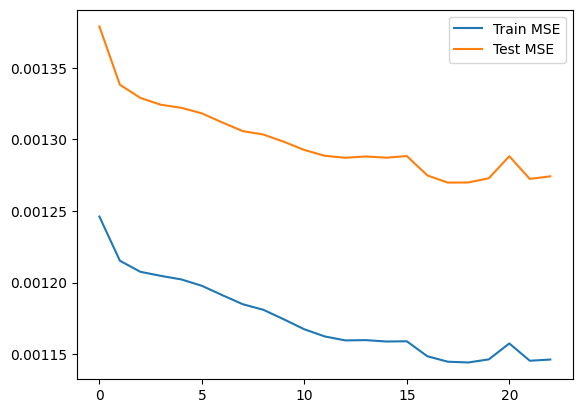

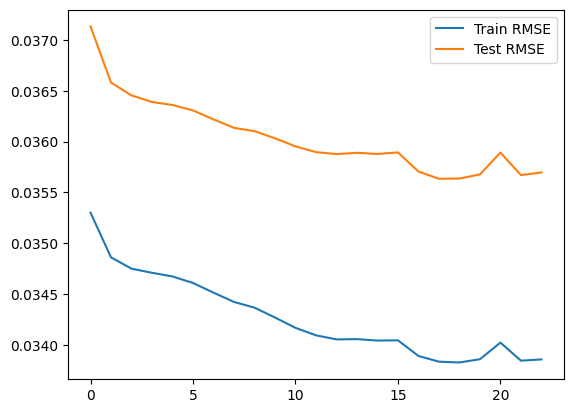

INFO logger 2026-01-06 22:49:04,873 | train_utils.py:140 | Best Loss: 9.92181402825321e-06, Best epoch: 23


In [27]:
trained_model = fit(model, X_train, y_train, X_val, y_val)